# Práctica 4: Razonamiento Basado en Casos con CBRkit

## Ingeniería del Conocimiento    2025/2026
### Prof. Juan A. Recio García

---

## Introducción

El **Razonamiento Basado en Casos (CBR)** es un paradigma de IA que resuelve nuevos problemas reutilizando soluciones de problemas similares del pasado. El ciclo CBR se compone de cuatro etapas:

1. **Retrieve** – Recuperar los casos más similares al problema actual.
2. **Reuse** – Adaptar la solución del caso recuperado al nuevo problema.
3. **Revise** – Evaluar y corregir la solución propuesta.
4. **Retain** – Almacenar el nuevo caso resuelto en la base de casos.

En esta práctica trabajaremos con la librería **CBRkit** para construir un sistema CBR aplicado a la **recomendación de coches de segunda mano**. Dado el perfil de un usuario que busca un coche, el sistema recuperará los vehículos más similares de la base de casos y adaptará el precio estimado.


---

## Dataset: Used Cars

Utilizaremos un subconjunto del dataset de coches de segunda mano disponible en Kaggle:  
🔗 https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

Cada caso representa un vehículo con los siguientes atributos:

| Atributo | Tipo | Descripción |
|---|---|---|
| `price` | Numérico | Precio en dólares (solución / target) |
| `year` | Numérico | Año de fabricación |
| `odometer` | Numérico | Kilometraje |
| `manufacturer` | Categórico | Marca del fabricante |
| `fuel` | Categórico | Tipo de combustible |
| `transmission` | Categórico | Tipo de transmisión |
| `condition` | Categórico | Estado del vehículo |
| `model` | Cadena | Modelo del vehículo |
| `title_status` | Categórico | Estado del título de propiedad |

> **Nota:** En CBR, el atributo `price` representa la **solución** del caso. Los demás atributos forman la **descripción del problema**.


---
## Parte 0: Instalación y preparación del entorno

Ejecuta la siguiente celda para importar CBRkit y sus dependencias necesarias.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cbrkit


---
## Parte 1: Carga y exploración del dataset

Construiremos un dataset sintético pero realista de coches de segunda mano, representativo del original de Kaggle. Esto permite trabajar sin necesidad de cuenta en Kaggle.

In [4]:
# Dataset sintético de coches de segunda mano
# Inspirado en: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

np.random.seed(42)

data = [
    {"id": 1,  "year": 2018, "manufacturer": "toyota",    "model": "camry se",           "condition": "good",       "odometer": 45000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 18500},
    {"id": 2,  "year": 2016, "manufacturer": "honda",     "model": "civic lx",           "condition": "good",       "odometer": 62000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 14200},
    {"id": 3,  "year": 2020, "manufacturer": "ford",      "model": "f-150 xlt",          "condition": "excellent",  "odometer": 15000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 32000},
    {"id": 4,  "year": 2015, "manufacturer": "chevrolet", "model": "silverado 1500",     "condition": "fair",       "odometer": 110000, "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 16500},
    {"id": 5,  "year": 2019, "manufacturer": "bmw",       "model": "3 series 330i",      "condition": "excellent",  "odometer": 22000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 28000},
    {"id": 6,  "year": 2017, "manufacturer": "toyota",    "model": "corolla le",         "condition": "good",       "odometer": 54000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 13500},
    {"id": 7,  "year": 2014, "manufacturer": "honda",     "model": "accord sport",       "condition": "good",       "odometer": 78000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 11800},
    {"id": 8,  "year": 2021, "manufacturer": "tesla",     "model": "model 3 standard",   "condition": "excellent",  "odometer": 8000,   "fuel": "electric","transmission": "automatic", "title_status": "clean",   "price": 38000},
    {"id": 9,  "year": 2016, "manufacturer": "ford",      "model": "mustang gt",         "condition": "good",       "odometer": 49000,  "fuel": "gas",     "transmission": "manual",    "title_status": "clean",   "price": 22000},
    {"id": 10, "year": 2013, "manufacturer": "chevrolet", "model": "cruze lt",           "condition": "fair",       "odometer": 95000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 7500},
    {"id": 11, "year": 2018, "manufacturer": "volkswagen","model": "jetta se",           "condition": "good",       "odometer": 38000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 16000},
    {"id": 12, "year": 2020, "manufacturer": "hyundai",   "model": "tucson sel",         "condition": "excellent",  "odometer": 18000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 23500},
    {"id": 13, "year": 2015, "manufacturer": "nissan",    "model": "altima s",           "condition": "fair",       "odometer": 88000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 9800},
    {"id": 14, "year": 2019, "manufacturer": "toyota",    "model": "rav4 xle",           "condition": "excellent",  "odometer": 24000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 27000},
    {"id": 15, "year": 2017, "manufacturer": "honda",     "model": "cr-v ex",            "condition": "good",       "odometer": 41000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 21000},
    {"id": 16, "year": 2012, "manufacturer": "ford",      "model": "focus se",           "condition": "fair",       "odometer": 102000, "fuel": "gas",     "transmission": "manual",    "title_status": "clean",   "price": 6200},
    {"id": 17, "year": 2020, "manufacturer": "chevrolet", "model": "equinox lt",         "condition": "excellent",  "odometer": 11000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 26500},
    {"id": 18, "year": 2016, "manufacturer": "bmw",       "model": "5 series 528i",      "condition": "good",       "odometer": 58000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22000},
    {"id": 19, "year": 2018, "manufacturer": "tesla",     "model": "model s 75d",        "condition": "excellent",  "odometer": 28000,  "fuel": "electric","transmission": "automatic", "title_status": "clean",   "price": 52000},
    {"id": 20, "year": 2014, "manufacturer": "volkswagen","model": "passat se",          "condition": "good",       "odometer": 72000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 10500},
    {"id": 21, "year": 2019, "manufacturer": "nissan",    "model": "rogue sv",           "condition": "excellent",  "odometer": 19000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22000},
    {"id": 22, "year": 2015, "manufacturer": "honda",     "model": "fit lx",             "condition": "good",       "odometer": 66000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 10200},
    {"id": 23, "year": 2021, "manufacturer": "hyundai",   "model": "elantra sel",        "condition": "excellent",  "odometer": 5000,   "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 19500},
    {"id": 24, "year": 2017, "manufacturer": "ford",      "model": "escape se",          "condition": "good",       "odometer": 47000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 17500},
    {"id": 25, "year": 2013, "manufacturer": "toyota",    "model": "prius two",          "condition": "fair",       "odometer": 91000,  "fuel": "hybrid",  "transmission": "automatic", "title_status": "clean",   "price": 11000},
    {"id": 26, "year": 2020, "manufacturer": "kia",       "model": "telluride ex",       "condition": "excellent",  "odometer": 14000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 35000},
    {"id": 27, "year": 2016, "manufacturer": "chevrolet", "model": "malibu lt",          "condition": "good",       "odometer": 55000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 13000},
    {"id": 28, "year": 2018, "manufacturer": "subaru",    "model": "outback 2.5i",       "condition": "good",       "odometer": 36000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22500},
    {"id": 29, "year": 2014, "manufacturer": "nissan",    "model": "sentra sv",          "condition": "fair",       "odometer": 84000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 8500},
    {"id": 30, "year": 2019, "manufacturer": "kia",       "model": "sportage lx",        "condition": "good",       "odometer": 29000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 19800},
    {"id": 31, "year": 2020, "manufacturer": "toyota",    "model": "camry xse",          "condition": "excellent",  "odometer": 12000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 26000},
    {"id": 32, "year": 2015, "manufacturer": "ford",      "model": "fusion se",          "condition": "good",       "odometer": 71000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 11500},
    {"id": 33, "year": 2017, "manufacturer": "honda",     "model": "pilot ex-l",         "condition": "good",       "odometer": 43000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 27500},
    {"id": 34, "year": 2018, "manufacturer": "subaru",    "model": "forester 2.5i",      "condition": "good",       "odometer": 33000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 21000},
    {"id": 35, "year": 2021, "manufacturer": "ford",      "model": "bronco sport big bend","condition": "excellent", "odometer": 7000,   "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 31000},
    {"id": 36, "year": 2013, "manufacturer": "chevrolet", "model": "impala ls",          "condition": "fair",       "odometer": 98000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 8000},
    {"id": 37, "year": 2019, "manufacturer": "volkswagen","model": "tiguan se",          "condition": "excellent",  "odometer": 21000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 25500},
    {"id": 38, "year": 2016, "manufacturer": "nissan",    "model": "pathfinder s",       "condition": "good",       "odometer": 60000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 17000},
    {"id": 39, "year": 2020, "manufacturer": "honda",     "model": "passport sport",     "condition": "excellent",  "odometer": 16000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 29000},
    {"id": 40, "year": 2014, "manufacturer": "toyota",    "model": "highlander le",      "condition": "good",       "odometer": 77000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 18000},
]

df = pd.DataFrame(data)
df.set_index("id", inplace=True)

print(f"Base de casos: {len(df)} vehículos")
df.head(10)

Base de casos: 40 vehículos


,year,manufacturer,model,condition,odometer,fuel,transmission,title_status,price
id,,,,,,,,,
1,2018,toyota,camry se,good,45000,gas,automatic,clean,18500
2,2016,honda,civic lx,good,62000,gas,automatic,clean,14200
3,2020,ford,f-150 xlt,excellent,15000,gas,automatic,clean,32000
4,2015,chevrolet,silverado 1500,fair,110000,gas,automatic,clean,16500
5,2019,bmw,3 series 330i,excellent,22000,gas,automatic,clean,28000
6,2017,toyota,corolla le,good,54000,gas,automatic,clean,13500
7,2014,honda,accord sport,good,78000,gas,automatic,clean,11800
8,2021,tesla,model 3 standard,excellent,8000,electric,automatic,clean,38000
9,2016,ford,mustang gt,good,49000,gas,manual,clean,22000


In [5]:
# Exploración básica del dataset
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Estadísticas numéricas ===")
print(df[["year", "odometer", "price"]].describe())
print("\n=== Atributos categóricos ===")
for col in ["manufacturer", "fuel", "transmission", "condition"]:
    print(f"  {col}: {df[col].unique()}")

=== Tipos de datos ===
year            int64
manufacturer      str
model             str
condition         str
odometer        int64
fuel              str
transmission      str
title_status      str
price           int64
dtype: object

=== Estadísticas numéricas ===
              year       odometer         price
count    40.000000      40.000000     40.000000
mean   2017.075000   47550.000000  20250.000000
std       2.565926   30382.982754   9521.150545
min    2012.000000    5000.000000   6200.000000
25%    2015.000000   20500.000000  12700.000000
50%    2017.000000   44000.000000  19650.000000
75%    2019.000000   71250.000000  26125.000000
max    2021.000000  110000.000000  52000.000000

=== Atributos categóricos ===
  manufacturer: <StringArray>
[    'toyota',      'honda',       'ford',  'chevrolet',        'bmw',
      'tesla', 'volkswagen',    'hyundai',     'nissan',        'kia',
     'subaru']
Length: 11, dtype: str
  fuel: <StringArray>
['gas', 'electric', 'hybrid']
Length: 

---
## Parte 2: Construcción de la base de casos en CBRkit

En CBRkit, la **base de casos** es un diccionario donde las claves son los identificadores de los casos y los valores son diccionarios con sus atributos.

También definiremos algunas **consultas de prueba** que representan coches que un usuario desea encontrar.

In [6]:
# Cargar la base de casos con CBRkit usando pandas
# Separamos la solución (price) de la descripción del problema
problem_attrs = ["year", "manufacturer", "model", "condition", "odometer", "fuel", "transmission", "title_status"]

# CBRkit puede cargar directamente desde pandas
casebase = cbrkit.loaders.pandas(df)

print(f"Casos cargados: {len(casebase)}")
print("\nEjemplo de caso (id=1):")
print(casebase[1])

Casos cargados: 40

Ejemplo de caso (id=1):
year                 2016
manufacturer        honda
model            civic lx
condition            good
odometer            62000
fuel                  gas
transmission    automatic
title_status        clean
price               14200
Name: 2, dtype: object


In [7]:
# Definición de consultas de prueba
# Cada consulta representa un nuevo cliente buscando coche

queries = {
    "query_1": {
        "year": 2018,
        "manufacturer": "toyota",
        "model": "camry le",
        "condition": "good",
        "odometer": 50000,
        "fuel": "gas",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None  # desconocido - esto es lo que queremos estimar
    },
    "query_2": {
        "year": 2020,
        "manufacturer": "tesla",
        "model": "model 3 long range",
        "condition": "excellent",
        "odometer": 10000,
        "fuel": "electric",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None
    },
    "query_3": {
        "year": 2015,
        "manufacturer": "honda",
        "model": "civic ex",
        "condition": "fair",
        "odometer": 85000,
        "fuel": "gas",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None
    }
}

print("Consultas definidas:")
for qid, qdata in queries.items():
    print(f"  {qid}: {qdata['year']} {qdata['manufacturer']} {qdata['model']} ({qdata['condition']}, {qdata['odometer']:,} km)")

Consultas definidas:
  query_1: 2018 toyota camry le (good, 50,000 km)
  query_2: 2020 tesla model 3 long range (excellent, 10,000 km)
  query_3: 2015 honda civic ex (fair, 85,000 km)


---
## Parte 3: Métricas de similitud

CBRkit ofrece métricas de similitud para distintos tipos de datos en el módulo `cbrkit.sim`. La **similitud global** entre dos casos se calcula combinando las similitudes locales de cada atributo mediante una función de agregación (normalmente la media ponderada).

### 3.1 Métricas para atributos numéricos (`cbrkit.sim.numbers`)

Para atributos como `year` y `odometer` usaremos métricas numéricas.

In [8]:
# Exploración de las métricas numéricas disponibles
# cbrkit.sim.numbers.linear: similitud lineal normalizada por un rango máximo
# cbrkit.sim.numbers.threshold: 1.0 si la diferencia es menor que un umbral, 0.0 en caso contrario

# Métrica lineal: sim = max(0, 1 - |x - y| / max_distance)
year_sim_linear = cbrkit.sim.numbers.linear(max=10)  # rango máximo de 10 años
odometer_sim_linear = cbrkit.sim.numbers.linear(max=150000)  # rango máximo de 150,000 km

# Prueba manual de las métricas
print("=== Similitud de AÑO (lineal, max=10) ===")
pairs_year = [(2018, 2018), (2018, 2019), (2018, 2020), (2018, 2015), (2018, 2010)]
for x, y in pairs_year:
    sim = year_sim_linear(x, y)
    print(f"  sim({x}, {y}) = {sim:.3f}")

print("\n=== Similitud de KILOMETRAJE (lineal, max=150000) ===")
pairs_odo = [(50000, 50000), (50000, 60000), (50000, 80000), (50000, 120000), (50000, 200000)]
for x, y in pairs_odo:
    sim = odometer_sim_linear(x, y)
    print(f"  sim({x:,}, {y:,}) = {sim:.3f}")

=== Similitud de AÑO (lineal, max=10) ===
  sim(2018, 2018) = 1.000
  sim(2018, 2019) = 0.900
  sim(2018, 2020) = 0.800
  sim(2018, 2015) = 0.700
  sim(2018, 2010) = 0.200

=== Similitud de KILOMETRAJE (lineal, max=150000) ===
  sim(50,000, 50,000) = 1.000
  sim(50,000, 60,000) = 0.933
  sim(50,000, 80,000) = 0.800
  sim(50,000, 120,000) = 0.533
  sim(50,000, 200,000) = 0.000


In [10]:
def plot_year(series, labels, years, reference_year):
    plt.figure(figsize=(10, 5))
    for s in series:
        plt.plot(years, s, marker='o', label=labels[series.index(s)])
    plt.xticks(ticks=years, labels=years)
    plt.title(f"Similitud de AÑO respecto a {reference_year}")
    plt.xlabel("Año comparado")
    plt.ylabel("Similitud")
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid()
    plt.show()

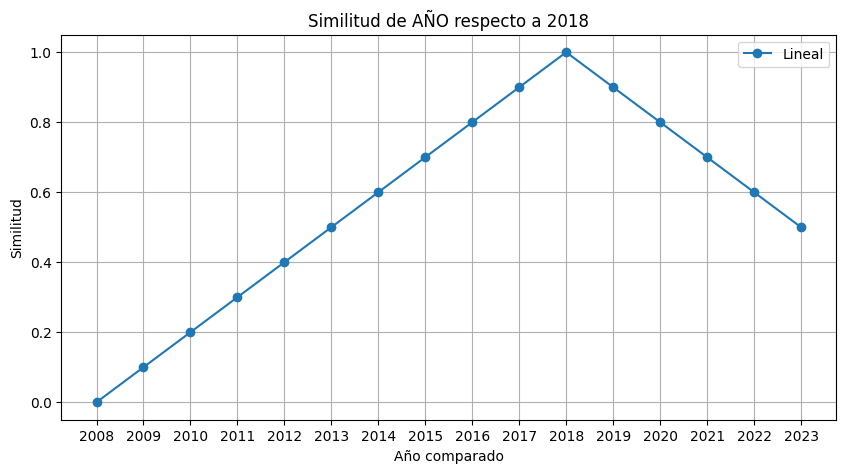

In [11]:
reference_year = 2018
years = list(range(2008, 2024))
year_sims = [year_sim_linear(reference_year, y) for y in years]
plot_year([year_sims], ['Lineal'], years, reference_year)

### **Ejercicio 1:** Comparación de métricas numéricas

Investiga las métricas numéricas `cbrkit.sim.numbers.exponential`, `cbrkit.sim.numbers.sigmoid`, `cbrkit.sim.numbers.threshold`.

1. Añadelas al código
2. Investiga los parámetros más apropiados.
3. ¿Cuál crees que es más apropiada para este dominio? Justifica tu respuesta en una celda de texto.

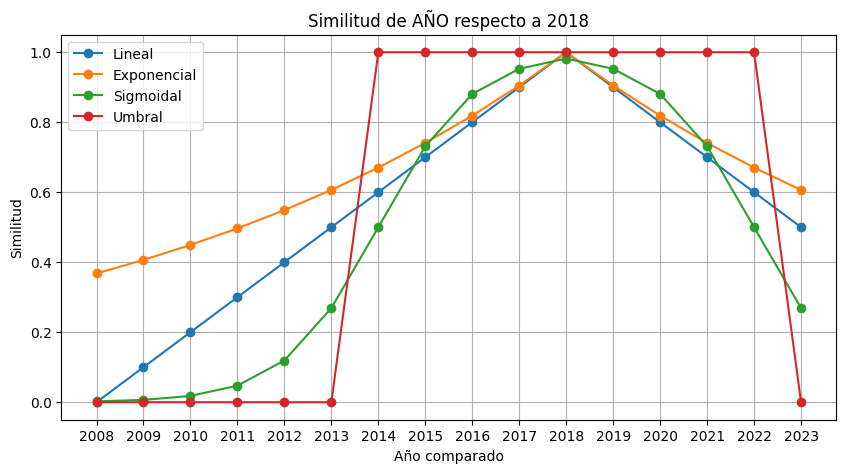

In [ ]:
# Ejercicio 1: Tu código aquí
year_sim_exponential = cbrkit.sim.numbers.exponential(0.1)
year_sim_sigmoid =  cbrkit.sim.numbers.sigmoid(1,3)
year_sim_threshold = cbrkit.sim.numbers.threshold(4)

# Compara las métricas
reference_year = 2018
years = list(range(2008, 2024))

linear_sims = [year_sim_linear(reference_year, y) for y in years]
exp_sims = [year_sim_exponential(reference_year, y) for y in years]
sig_sims = [year_sim_sigmoid(reference_year, y) for y in years]
thr_sims = [year_sim_threshold(reference_year, y) for y in years]


plot_year([linear_sims, exp_sims, sig_sims, thr_sims], ['Lineal', 'Exponencial', 'Sigmoidal', 'Umbral'], years, reference_year)



*Escribe aquí tu análisis del Ejercicio 1...*

### 3.2 Métricas para atributos categóricos (`cbrkit.sim.generic`)

Para atributos como `fuel`, `transmission` o `condition` podemos usar:
- **`equality`**: 1.0 si son iguales, 0.0 si no lo son.
- **`table`**: define similitudes personalizadas entre pares de valores.
- Una función personalizada.

In [ ]:
# Métrica de igualdad (la más básica para categóricos)
equality_sim = cbrkit.sim.generic.equality()

print("=== Similitud de COMBUSTIBLE (igualdad) ===")
fuels = [("gas", "gas"), ("gas", "electric"), ("gas", "hybrid"), ("electric", "electric")]
for x, y in fuels:
    print(f"  sim({x}, {y}) = {equality_sim(x, y):.1f}")

In [ ]:
# Métrica de tabla: permite definir similitudes parciales entre valores categóricos
# Útil cuando hay una relación semántica entre las categorías

# Para el atributo 'condition', hay un orden natural: excellent > good > fair > salvage
condition_sim_table = cbrkit.sim.generic.table(
    {
        ("excellent", "excellent"): 1.0,
        ("excellent", "good"):      0.7,
        ("excellent", "fair"):      0.3,
        ("excellent", "salvage"):   0.0,
        ("good",      "excellent"): 0.7,
        ("good",      "good"):      1.0,
        ("good",      "fair"):      0.5,
        ("good",      "salvage"):   0.1,
        ("fair",      "excellent"): 0.3,
        ("fair",      "good"):      0.5,
        ("fair",      "fair"):      1.0,
        ("fair",      "salvage"):   0.2,
        ("salvage",   "excellent"): 0.0,
        ("salvage",   "good"):      0.1,
        ("salvage",   "fair"):      0.2,
        ("salvage",   "salvage"):   1.0,
    },
    default=0.0
)

print("=== Similitud de CONDICIÓN (tabla personalizada) ===")
conditions = ["excellent", "good", "fair", "salvage"]
for c1 in conditions:
    for c2 in conditions:
        sim = condition_sim_table(c1, c2)
        print(f"  sim({c1:10s}, {c2:10s}) = {sim:.1f}")

In [ ]:
# Visualizar la matriz de similitud para 'condition'
conditions = ["excellent", "good", "fair", "salvage"]
matrix = [[condition_sim_table(c1, c2) for c2 in conditions] for c1 in conditions]
matrix_df = pd.DataFrame(matrix, index=conditions, columns=conditions)

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Matriz de similitud para 'condition'")
plt.tight_layout()
plt.show()

### **Ejercicio 2:** Métrica para el atributo `fuel`

La igualdad exacta para `fuel` puede ser demasiado estricta. Por ejemplo, `hybrid` es más cercano a `electric` que a `gas`.

1. Crea una **métrica de tabla** para el atributo `fuel` que tenga en cuenta estas similitudes parciales.
2. Visualiza la matriz de similitud resultante.
3. Justifica tus elecciones de valores en una celda de texto.

In [ ]:
# Ejercicio 2: Tu código aquí
# Valores posibles de fuel: gas, electric, hybrid, diesel, other

fuel_sim = cbrkit.sim.generic.table(
    {
        # TODO: Define las similitudes entre tipos de combustible
        # Recuerda: sim(x, x) = 1.0 siempre
        # ¿Cuánto se parece 'hybrid' a 'gas'? ¿Y 'diesel' a 'gas'?
    },
    default=0.0
)

# TODO: Visualiza la matriz de similitud

*Escribe aquí tu justificación del Ejercicio 2...*

### 3.3 Métricas para atributos de texto (`cbrkit.sim.strings`)

El atributo `model` es una cadena de texto libre (ej. "camry se", "camry xse"). Para compararlo usaremos métricas de similitud de strings:

In [ ]:
# Métricas de similitud de cadenas disponibles en CBRkit
# Necesitamos instalar la dependencia 'nlp' de cbrkit para Levenshtein y Jaro
%pip install levenshtein --quiet

In [ ]:

# Métrica de Levenshtein: basada en distancia de edición
levenshtein_sim = cbrkit.sim.strings.levenshtein()

# Métrica de Jaro-Winkler: mejor para nombres y cadenas cortas
jaro_sim = cbrkit.sim.strings.jaro_winkler()

print("=== Comparación de métricas de STRING para 'model' ===")
model_pairs = [
    ("camry se", "camry se"),       # igual
    ("camry se", "camry le"),       # muy similar (mismo modelo, trim diferente)
    ("camry se", "camry xse"),      # similar
    ("camry se", "corolla le"),     # misma marca, modelo diferente
    ("camry se", "f-150 xlt"),      # completamente diferente
]

print(f"{'Par':<35} {'Levenshtein':>12} {'Jaro-Winkler':>12}")
print("-" * 62)
for x, y in model_pairs:
    lev = levenshtein_sim(x, y)
    jaro = jaro_sim(x, y)
    print(f"  ({x!r}, {y!r})   {lev:>12.3f} {jaro:>12.3f}")

In [ ]:
# También podemos definir una función personalizada
# CBRkit exige que los parámetros se llamen x e y

def model_sim_prefix(x: str, y: str) -> float:
    """
    Similitud para el modelo del coche:
    - Coincidencia exacta: 1.0
    - La primera palabra (nombre de modelo) coincide: 0.7
    - La primera palabra NO coincide: basado en Jaro
    """
    if x == y:
        return 1.0
    x_parts = x.lower().split()
    y_parts = y.lower().split()
    if x_parts[0] == y_parts[0]:
        return 0.7
    # Si las primeras palabras son distintas, similitud baja
    return 0.1

print("=== Función personalizada 'model_sim_prefix' ===")
for x, y in model_pairs:
    sim = model_sim_prefix(x, y)
    print(f"  ({x!r}, {y!r}) => {sim:.2f}")

---
## Parte 4: Pipeline de recuperación completo

Ahora combinaremos todas las métricas locales en un **pipeline de recuperación** usando `cbrkit.sim.attribute_value` para definir la similitud global, y `cbrkit.retrieval.build` para construir el retriever.

### 4.1 Primer retriever: similitud básica

In [ ]:
# Definición del retriever básico
# attribute_value combina similitudes locales mediante media ponderada

base_retriever = cbrkit.retrieval.build(
    cbrkit.sim.attribute_value(
        attributes={
            "year":         year_sim_linear,
            "odometer":     odometer_sim_linear,
            "manufacturer": equality_sim,
            "fuel":         equality_sim,
            "transmission": equality_sim,
            "condition":    equality_sim,
            "model":        levenshtein_sim,
        },
        aggregator=cbrkit.sim.aggregator(pooling="mean", 
            pooling_weights={
            "year":         0.20,
            "odometer":     0.20,
            "manufacturer": 0.20,
            "fuel":         0.10,
            "transmission": 0.05,
            "condition":    0.15,
            "model":        0.10,
        })
    )
)
retriever_basic = cbrkit.retrieval.dropout(base_retriever, limit=5)
print("Retriever básico construido")

In [ ]:
# Ejecutar la recuperación para la primera consulta
query = queries["query_1"]
print(f"Consulta: {query['year']} {query['manufacturer']} {query['model']}")
print(f"         Condición: {query['condition']}, Kilometraje: {query['odometer']:,}\n")

result = cbrkit.retrieval.apply.apply_query(casebase, query, retriever_basic)

step  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")

In [ ]:
(a, b) = result
b

### 4.2 Segundo retriever: métricas mejoradas

Ahora construiremos un segundo retriever que use las métricas más elaboradas que hemos definido.

In [ ]:
# Retriever mejorado con las métricas personalizadas
# NOTA: Antes de ejecutar esto, asegúrate de haber completado el Ejercicio 2
# Si no, puedes usar equality_sim para fuel como placeholder

base_retriever_improved = cbrkit.retrieval.build(
    cbrkit.sim.attribute_value(
        attributes={
            "year":         year_sim_exponential,   # función exponencial personalizada
            "odometer":     odometer_sim_linear,
            "manufacturer": equality_sim,
            "fuel":         equality_sim,            # TODO: sustituir por fuel_sim del Ejercicio 2
            "transmission": equality_sim,
            "condition":    condition_sim_table,     # tabla de similitud semántica
            "model":        model_sim_prefix,        # función personalizada de prefijos
        },
        aggregator=cbrkit.sim.aggregator(pooling="mean", 
            pooling_weights={
            "year":         0.20,
            "odometer":     0.20,
            "manufacturer": 0.20,
            "fuel":         0.10,
            "transmission": 0.05,
            "condition":    0.15,
            "model":        0.10,
        })
    )
)


retriever_improved = cbrkit.retrieval.dropout(base_retriever_improved, limit=5)
print("Retriever mejorado construido")


result = cbrkit.retrieval.apply.apply_query(casebase, query, retriever_improved)

step  = result.steps[-1]
qstep = list(step.queries.values())[0]


print("Top-5 con retriever MEJORADO:")
tep  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")

### **Ejercicio 3:** Comparación de retrievers

1. Ejecuta ambos retrievers (básico y mejorado) sobre otras tres consultas distintas.
2. Para cada consulta, muestra una tabla comparando el top-3 recuperado por cada retriever.
3. ¿Los resultados difieren significativamente? ¿Cuándo las mejoras son más notables?

*Escribe aquí tu análisis del Ejercicio 3...*

### **Ejercicio 4:** Efecto de los pesos en el retrieval

Los pesos en `pooling_weights` controlan la importancia relativa de cada atributo en la similitud global.

1. Crea un tercer retriever `retriever_km_focused` donde el kilometraje tenga un peso de **0.40** (reduce los otros atributos proporcionalmente).
2. Compara sus resultados con el retriever mejorado para `query_3` (el coche con mayor kilometraje).
3. ¿Qué atributos tienen mayor impacto en los resultados?

In [ ]:
# Ejercicio 4: Tu código aquí
retriever_km_focused = cbrkit.retrieval.build(
...
)


# Compara para query_3
# TODO: Ejecuta y compara

---
## Parte 5: Adaptación de la solución (Reuse)

Una vez recuperados los casos más similares, la etapa de **Reuse** adapta su solución al nuevo problema. En nuestro dominio, la "solución" es el **precio** del vehículo.

Implementaremos una función de adaptación que **estima el precio** del vehículo consulta en base a los casos recuperados.

### 5.1 Adaptación simple: media ponderada de precios

In [ ]:
# Función de adaptación: media ponderada de precios por similitud
# En CBRkit, una función de reuse acepta (case, query) y devuelve el caso adaptado

def adapt_price_weighted_mean(case: dict, query: dict) -> dict:
    """
    Adaptación trivial: devuelve el precio del caso más similar sin modificación.
    Este es el caso más simple de reuse (copia directa).
    """
    adapted = dict(case)  # copia del caso
    # El precio no se adapta, se reutiliza directamente
    return adapted

print("Función de adaptación básica definida")

# Construcción del pipeline completo: retrieval + reuse
reuser_basic = cbrkit.reuse.build(adapt_price_weighted_mean, retriever_basic)
print("Reuser construido")

In [ ]:
# Pipeline completo: primero retrieve, luego reuse
query = queries["query_1"]


# Paso 2: Reuse (adaptación trivial - precio directo)
reuse_result = cbrkit.reuse.apply.apply_query(casebase, query, reuser_basic)

step  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")


In [ ]:
reuse_result

### **Ejercicio 5:** Implementa tu propia función de adaptación

La función de adaptación anterior solo considera año, kilometraje y condición. Mejórala añadiendo:

1. Una corrección cuando el **tipo de combustible** es diferente (ej., los coches eléctricos suelen ser más caros que los de gasolina equivalentes).
2. Una corrección cuando el **fabricante** es distinto (ej., marcas de lujo como BMW tienen precios más altos).
3. Prueba tu función de adaptación mejorada en las tres consultas y compara los precios estimados con la versión anterior.

In [ ]:
# Ejercicio 5: Tu código aquí

# Sugerencia: define factores de precio por tipo de combustible y marca
FUEL_PRICE_FACTOR = {
    "electric": 1.15,  # coches eléctricos son ~15% más caros
    "hybrid":   1.05,
    "gas":      1.00,
    "diesel":   1.02,
    "other":    0.95,
}

MANUFACTURER_TIER = {
    # TODO: Asigna factores de precio a las marcas
    # premium: bmw, tesla, mercedes-benz, audi, lexus → ~1.20
    # mid: honda, toyota, volkswagen, subaru → ~1.00
    # budget: chevrolet, ford, nissan, hyundai, kia → ~0.90
}

def adapt_price_advanced_v2(case: dict, query: dict) -> dict:
    """
    Función de adaptación mejorada que incluye correcciones por
    combustible y fabricante además de año y kilometraje.
    """
    # TODO: Implementa la función de adaptación mejorada
    pass

# reuser_v2 = cbrkit.reuse.build(adapt_price_advanced_v2)
# Prueba tu función aquí

*Escribe aquí tu análisis del Ejercicio 5...*

---
## Parte 7: Preguntas de reflexión

Responde a las siguientes preguntas en celdas de texto adicionales:

**Q1.** ¿Qué ventajas tiene usar una tabla de similitud semántica para `condition` frente a la igualdad exacta? ¿Puedes pensar en algún dominio donde la igualdad exacta sea siempre la opción correcta?

**Q2.** Los pesos de los atributos modelan la importancia relativa de cada uno. Si el sistema está orientado a compradores que priorizan el ahorro de combustible, ¿cómo modificarías los pesos?

**Q3.** La función de adaptación asume una depreciación lineal por año y por kilómetro. ¿Es esta una suposición razonable? ¿Qué modelo de depreciación sería más realista?

**Q4.** ¿Cómo implementarías la fase de **Retain** en este sistema? ¿Bajo qué condiciones añadirías un nuevo caso a la base?

**Q5.** CBRkit soporta embedding semántico (`cbrkit.sim.embed`) para comparar textos. ¿En qué situaciones del dominio del coche podría ser útil? ¿Qué limitaciones tendría?

**Q1.** *Tu respuesta aquí...*

**Q2.** *Tu respuesta aquí...*

**Q3.** *Tu respuesta aquí...*

**Q4.** *Tu respuesta aquí...*

**Q5.** *Tu respuesta aquí...*